## <u>Import Libraries</u>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
from torchvision.datasets import MNIST
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

/opt/anaconda3/envs/pytorch/lib/python3.10/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/anaconda3/envs/pytorch/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <0B7EB158-53DC-3403-8A49-22178CAB4612> /opt/anaconda3/envs/pytorch/lib/python3.10/site-packages/torchvision/image.so
  Reason: tried: '/opt/anaconda3/envs/pytorch/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/pytorch/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/pytorch/lib/python3.10/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/anaconda3/envs/pytorch/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `li

---
## <u>Image Transformations & Load Dataset</u>

Same transform as the RNN and LSTM builds on this dataset: MNIST is grayscale, 1 channel, so `Normalize` takes one mean/std pair, `(0.1307,)` and `(0.3081,)`, its real known statistics.

`torchvision.datasets.MNIST` auto downloads on first run. `train=True`/`train=False` correctly pull the separate 60,000 image training set and 10,000 image test set here.

In [2]:
transformations = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_set = MNIST("../dataset", train=True, download=True, transform=transformations)
test_set = MNIST("../dataset", train=False, download=True, transform=transformations)

print(len(train_set), len(test_set))
print(train_set[0][0].shape)  # (1 colour channel, 28 rows, 28 columns)

60000 10000
torch.Size([1, 28, 28])


---
## <u>Train, Validation, Test Split</u>

Every prior notebook in this project used only `train_loader` and `test_loader`, with `test_loader` doing two jobs at once: deciding which epoch's weights to checkpoint (`best_val_loss`), and then reporting the final accuracy. That is a real, if subtle, leakage problem: the test set was helping choose the model before being used to grade it, so the final reported number ends up slightly optimistic, not a fully honest measure of generalization to truly unseen data. Not leakage into the model's weights (`test_loader` never touches `.backward()` or `optimizer.step()`), but leakage into the reported result.

The fix: split `train_set` itself into a real training portion and a validation portion. Validation, carved out of training data, is what decides checkpointing during the loop. The genuine `test_set` (MNIST's separate 10,000 image holdout, `train=False`) is touched exactly once, after training is completely finished, purely to report the final number, never to make any decision along the way.

In [3]:
# splitting train_set itself into a training portion and a validation portion
# validation is what decides checkpointing during training, not the real test set
# generator with a fixed seed keeps the split reproducible, same convention as random_state=42 elsewhere
train_subset, val_subset = torch.utils.data.random_split(
    train_set,
    [0.9, 0.1],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)  # carved from training data, used for checkpointing
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)   # untouched until final evaluation, used exactly once

---
## <u>Model Architecture</u>

Same conv, ReLU, max pool pattern as CIFAR10 and cat/dog, three stages here instead of two, with one difference worth naming up front: MNIST images are grayscale, 1 input channel, not 3 like RGB photos, so the first conv layer's `in_channels` is `1`, not `3`.

**Why the channel count grows while spatial size shrinks, the same trade off as every prior CNN:** each conv layer's `out_channels` is simply how many filters that layer uses, a number chosen deliberately (`num_filters`, `num_filters*2`, `num_filters*4`), not derived from the input. Each filter spans the full input depth but produces one output map, so stacking `N` filters gives `N` output channels. Padding (`padding=1` with `kernel_size=3`) keeps spatial size unchanged through each conv, `output = input - kernel + 2*padding + 1 = 28 - 3 + 2 + 1 = 28`. `MaxPool2d(2,2)` is what actually shrinks spatial size, halving height and width, leaving channel count untouched, since pooling has no filters.

One new wrinkle at the third pooling step: `7` is odd. `MaxPool2d` fits three complete 2x2 windows across 7 pixels (covering positions 0 to 5) and simply drops the 7th, unpaired pixel rather than padding or rounding up. `7 -> 3`, floor division, and a thin strip of real pixel information along that edge is discarded in the process, not merged in.

Shape flow through this architecture, with `num_filters=32`:
```
1x28x28    -> conv, 32 filters  -> 32x28x28  -> maxpool 2x2 -> 32x14x14
32x14x14   -> conv, 64 filters  -> 64x14x14  -> maxpool 2x2 -> 64x7x7
64x7x7     -> conv, 128 filters -> 128x7x7   -> maxpool 2x2 -> 128x3x3
128x3x3    -> flatten -> 1152 values
```

`nn.Linear(self.num_filters * 4 * 3 * 3, 128)` is written in terms of `num_filters` rather than a hardcoded number, so it stays correct if `num_filters` is ever changed, `32*4*3*3 = 1152`, matching the flattened conv output exactly. Dropout (0.3) sits after the first FC layer's ReLU, the largest single concentration of parameters in the whole network, same reasoning as every prior CNN for where dropout does the most good. No activation on the final layer, `CrossEntropyLoss` applies softmax internally.

In [4]:
class CNN(nn.Module):
    def __init__(self, input_size, num_classes, num_filters):
        super(CNN, self).__init__()

        self.input_size = input_size
        self.num_classes = num_classes
        self.num_filters = num_filters

        self.cnn = nn.Sequential(
            # (in_channels, out_channels, kernel_size, padding)
            # input size : 1, 28, 28
            nn.Conv2d(1, self.num_filters, kernel_size=3, padding=1),  # 32, 28, 28
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 32, 14, 14

            nn.Conv2d(self.num_filters, (self.num_filters * 2), kernel_size=3, padding=1),  # 64, 14, 14
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 64, 7, 7

            nn.Conv2d((self.num_filters * 2), (self.num_filters * 4), kernel_size=3, padding=1),  # 128, 7, 7
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 7 is odd, floors down to 3: 128, 3, 3

        )

        self.fc = nn.Sequential(
            nn.Linear(self.num_filters * 4 * 3 * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, self.num_classes)
        )

    def forward(self, x):
        x_conv = self.cnn(x)
        x_flat = x_conv.view(x_conv.size(0), -1)  # flatten (batch, 128, 3, 3) -> (batch, 1152)
        x_fc = self.fc(x_flat)

        return x_fc

---
## <u>Compile the Model</u>

In [5]:
input_size = 28
num_classes = 10
num_filters = 32

model = CNN(input_size, num_classes, num_filters)

loss_func = nn.CrossEntropyLoss()  # multiclass, applies softmax internally
optimizer = optim.Adam(model.parameters())

---
## <u>Train the Model</u>

Same skeleton as every prior build: outer epoch loop, `model.train()`/`model.eval()`, the five step batch sequence, checkpoint on best validation loss.

The validation half of the loop runs over `val_loader`, carved out of training data. `test_loader` does not appear anywhere in this cell.

In [6]:
epochs = 10

train_loss_history = []
val_loss_history = []
best_val_loss = float("inf")
best_epoch = 1

for epoch in range(epochs):
    model.train()
    total_train_loss = 0.0

    for x_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred_tensors = model(x_batch)
        batch_loss = loss_func(y_pred_tensors, y_batch)
        batch_loss.backward()
        optimizer.step()

        total_train_loss = total_train_loss + batch_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)

    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:  # validation set, carved from training data, not the real test set
            y_pred_tensors = model(x_batch)
            batch_loss = loss_func(y_pred_tensors, y_batch)

            total_val_loss = total_val_loss + batch_loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_loss_history.append(avg_val_loss)

    print(f"epoch = {epoch + 1}/{epochs} -----------> train loss = {avg_train_loss} -----------> validation loss = {avg_val_loss}")

    if best_val_loss > avg_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_cnn_model.pt")

print("best model at epoch : ", best_epoch)

epoch = 1/10 -----------> train loss = 0.24565102848537726 -----------> validation loss = 0.06814322370213476
epoch = 2/10 -----------> train loss = 0.0677449106993551 -----------> validation loss = 0.04877807191285761
epoch = 3/10 -----------> train loss = 0.04746175017560969 -----------> validation loss = 0.03573088549099803
epoch = 4/10 -----------> train loss = 0.03704011126452289 -----------> validation loss = 0.039065323062265844
epoch = 5/10 -----------> train loss = 0.029814094074966466 -----------> validation loss = 0.034292002820020956
epoch = 6/10 -----------> train loss = 0.02543792169501396 -----------> validation loss = 0.029710217775341045
epoch = 7/10 -----------> train loss = 0.022669958732376688 -----------> validation loss = 0.031068501937663816
epoch = 8/10 -----------> train loss = 0.017792146894802182 -----------> validation loss = 0.034115482536629105
epoch = 9/10 -----------> train loss = 0.01622681682952845 -----------> validation loss = 0.04091551698288543
epo

---
## <u>Plot the Loss Curves</u>

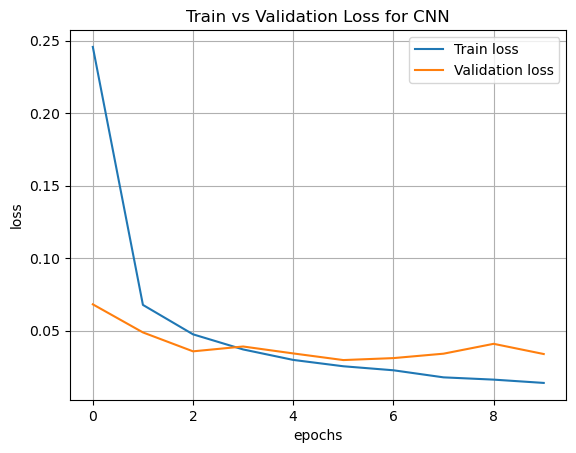

In [7]:
df_loss = pd.DataFrame({
    "Train loss": train_loss_history,
    "Validation loss": val_loss_history
})

plt.plot(df_loss["Train loss"], label="Train loss")
plt.plot(df_loss["Validation loss"], label="Validation loss")

plt.title("Train vs Validation Loss for CNN")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.grid(True)
plt.legend()
plt.show()

---
## <u>Load Best Checkpoint</u>

In [8]:
model.load_state_dict(torch.load("best_cnn_model.pt", weights_only=True))

<All keys matched successfully>

---
## <u>Evaluate</u>

Same batch accumulated pattern as every prior image build: loop over each loader, collect predictions and labels batch by batch, `torch.cat` together, compute metrics once on the full set. `dim=1` in `argmax` searches across each image's 10 class scores. `average='weighted'` since this is multiclass.

`test_loader` appears only here, used exactly once, after training and checkpoint selection are both finished.

In [9]:
model.eval()

all_train_preds = []
all_train_labels = []
all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for x_train_batch, y_train_batch in train_loader:

        y_train_pred_tensor = model(x_train_batch)
        predicted_train_classes = torch.argmax(y_train_pred_tensor, dim=1)

        all_train_preds.append(predicted_train_classes)
        all_train_labels.append(y_train_batch)

    for x_test_batch, y_test_batch in test_loader:  # untouched until now

        y_test_pred_tensor = model(x_test_batch)
        predicted_test_classes = torch.argmax(y_test_pred_tensor, dim=1)

        all_test_preds.append(predicted_test_classes)
        all_test_labels.append(y_test_batch)

all_train_preds = torch.cat(all_train_preds)
all_train_labels = torch.cat(all_train_labels)
all_test_preds = torch.cat(all_test_preds)
all_test_labels = torch.cat(all_test_labels)

print("For Training:")
print(f"Accuracy Score : {accuracy_score(all_train_labels.numpy(), all_train_preds.numpy())}")
print(f"Precision Score : {precision_score(all_train_labels.numpy(), all_train_preds.numpy(), average='weighted')}")
print(f"Recall Score : {recall_score(all_train_labels.numpy(), all_train_preds.numpy(), average='weighted')}")
print(f"F1 Score : {f1_score(all_train_labels.numpy(), all_train_preds.numpy(), average='weighted')}")
print("\n")
print("For Testing:")
print(f"Accuracy Score : {accuracy_score(all_test_labels.numpy(), all_test_preds.numpy())}")
print(f"Precision Score : {precision_score(all_test_labels.numpy(), all_test_preds.numpy(), average='weighted')}")
print(f"Recall Score : {recall_score(all_test_labels.numpy(), all_test_preds.numpy(), average='weighted')}")
print(f"F1 Score : {f1_score(all_test_labels.numpy(), all_test_preds.numpy(), average='weighted')}")

For Training:
Accuracy Score : 0.9961851851851852
Precision Score : 0.9961907314652559
Recall Score : 0.9961851851851852
F1 Score : 0.9961846705563561


For Testing:
Accuracy Score : 0.9916
Precision Score : 0.9916151676759102
Recall Score : 0.9916
F1 Score : 0.9915974556151274
